<a href="https://colab.research.google.com/github/ahmdfrhn123/Sentiment-Analysis-BERT-Used-SMOTE/blob/main/80_20_Unsmote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

<ipython-input-1-8858b73e3fdb>:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(input_ids_train, dtype=torch.long)  # Pastikan dtype adalah long
<ipython-input-1-8858b73e3fdb>:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_masks_train_tensor = torch.tensor(attention_masks_train, dtype=torch.long)  # Pastikan dtype adalah long
<ipython-input-1-8858b73e3fdb>:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(input_ids_test, dtype=torch.long)
<ipython-input-1-8858b73e3fd

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training...
Epoch 1/10
750/750 ━━━━━━━━━━━━ accuracy: 0.8305 - loss: 0.4987 - val_accuracy: 0.8653
Epoch 2/10
750/750 ━━━━━━━━━━━━ accuracy: 0.8715 - loss: 0.3918 - val_accuracy: 0.8700
Epoch 3/10
750/750 ━━━━━━━━━━━━ accuracy: 0.8860 - loss: 0.3490 - val_accuracy: 0.8650
Epoch 4/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9004 - loss: 0.3036 - val_accuracy: 0.8667
Epoch 5/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9144 - loss: 0.2552 - val_accuracy: 0.8653
Epoch 6/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9306 - loss: 0.2064 - val_accuracy: 0.8483
Epoch 7/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9433 - loss: 0.1693 - val_accuracy: 0.8480
Epoch 8/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9537 - loss: 0.1384 - val_accuracy: 0.8510
Epoch 9/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9654 - loss: 0.1085 - val_accuracy: 0.8537
Epoch 10/10
750/750 ━━━━━━━━━━━━ accuracy: 0.9700 - loss: 0.0992 - val_accuracy: 0.8407


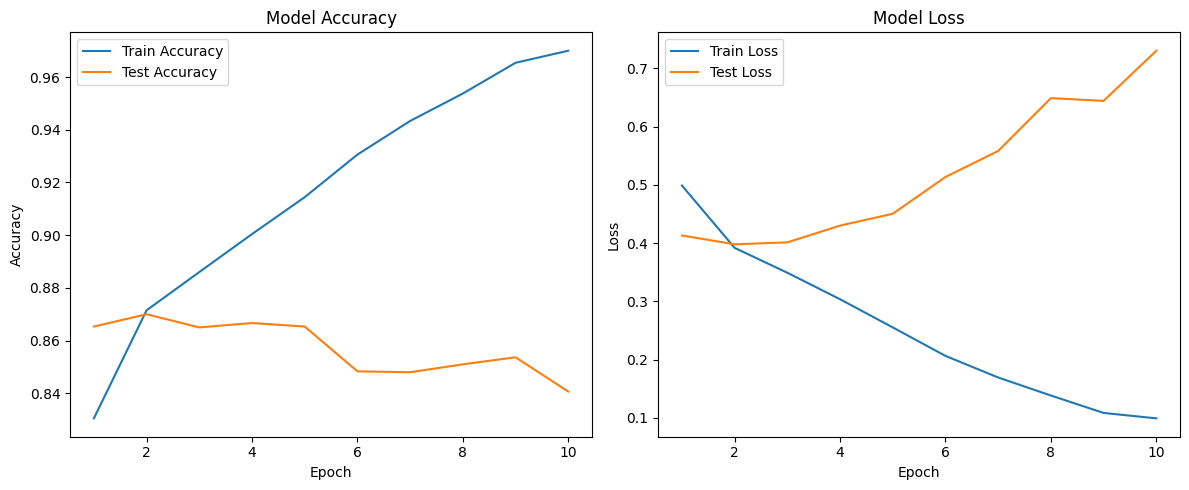


Data Per Epoch:
   Epoch  Train Loss  Train Accuracy  Test Loss  Test Accuracy
0      1    0.498740        0.830500   0.413005       0.865333
1      2    0.391765        0.871500   0.397893       0.870000
2      3    0.349044        0.886000   0.401244       0.865000
3      4    0.303625        0.900417   0.430017       0.866667
4      5    0.255250        0.914417   0.450336       0.865333
5      6    0.206395        0.930583   0.513410       0.848333
6      7    0.169325        0.943333   0.558104       0.848000
7      8    0.138406        0.953750   0.648722       0.851000
8      9    0.108485        0.965417   0.644011       0.853667
9     10    0.099225        0.970000   0.730100       0.840667

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1773
           1       0.12      0.10      0.11       165
           2       0.93      0.80      0.86      1062

    accuracy                           0.84      3

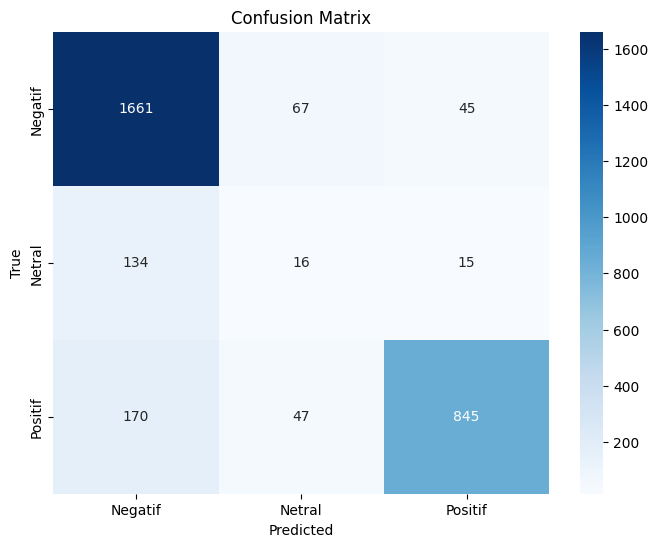

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
import re
import torch
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from tabulate import tabulate

# 1. Memuat data
df = pd.read_csv('/content/ULASAN_IKD_15000.csv')

# 2. Membersihkan kolom yang tidak diperlukan
df = df.drop(columns=['reviewId', 'userName', 'userImage', 'thumbsUpCount',
                      'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion'])

# 3. Fungsi untuk membersihkan teks ulasan
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Hapus URL
    text = re.sub(r'\@\w+|\#', '', text)  # Hapus mention dan hashtag
    text = re.sub(r'\d+', '', text)  # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    text = text.lower()  # Huruf kecil semua
    return text

# Terapkan fungsi pembersihan
df['cleaned_review_text'] = df['content'].apply(clean_text)

# 4. Membuat label sentimen berdasarkan score
def create_sentiment_label(score):
    if score <= 2:
        return 0  # Negatif
    elif score == 3:
        return 1  # Netral
    else:
        return 2  # Positif

df['sentiment'] = df['score'].apply(create_sentiment_label)

# 5. Pisahkan fitur dan label
X = df['cleaned_review_text']
y = df['sentiment']

# 6. Pisahkan data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Tokenisasi dan padding menggunakan BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_length = 128  # Panjang maksimum token

def tokenize_and_pad(texts, tokenizer, max_length):
    encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_length, return_tensors='pt')
    return encodings['input_ids'], encodings['attention_mask']

# Tokenisasi data training
input_ids_train, attention_masks_train = tokenize_and_pad(X_train, tokenizer, max_length)

# Tokenisasi data testing
input_ids_test, attention_masks_test = tokenize_and_pad(X_test, tokenizer, max_length)

# Encode label
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 8. Konversi kembali ke tensor
X_train_tensor = torch.tensor(input_ids_train, dtype=torch.long)  # Pastikan dtype adalah long
attention_masks_train_tensor = torch.tensor(attention_masks_train, dtype=torch.long)  # Pastikan dtype adalah long
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)  # Pastikan dtype adalah long

X_test_tensor = torch.tensor(input_ids_test, dtype=torch.long)
attention_masks_test_tensor = torch.tensor(attention_masks_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# 9. Buat DataLoader untuk training
train_data = TensorDataset(X_train_tensor, attention_masks_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_data, sampler=RandomSampler(train_data), batch_size=16)

# Proses data testing tanpa SMOTE
test_data = TensorDataset(X_test_tensor, attention_masks_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_data, sampler=SequentialSampler(test_data), batch_size=16)

# 10. Memuat model BERT untuk klasifikasi
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
optimizer = AdamW(model.parameters(), lr=2e-5)

# Proses Pelatihan
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

training_losses = []
testing_losses = []  # Tambahkan untuk menyimpan test loss
training_accuracies = []
testing_accuracies = []
epochs = 10

# Data untuk tabel per epoch
epoch_data = []

print("Training...")
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_dataloader:
        b_input_ids = batch[0].to(device)
        b_attention_masks = batch[1].to(device)
        b_labels = batch[2].to(device)

        optimizer.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_attention_masks, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == b_labels).sum().item()
        total += b_labels.size(0)

    avg_loss = total_loss / len(train_dataloader)
    training_losses.append(avg_loss)
    training_accuracies.append(correct / total)

    # Evaluasi pada data testing
    model.eval()
    test_total_loss = 0  # Inisialisasi total loss untuk test
    test_correct = 0
    test_total = 0

    for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_attention_masks = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, attention_mask=b_attention_masks, labels=b_labels)  # Berikan labels untuk menghitung loss
            logits = outputs.logits
            loss = outputs.loss  # Ambil loss untuk test

        test_total_loss += loss.item()  # Tambahkan ke total loss test
        preds = torch.argmax(logits, dim=1)
        test_correct += (preds == b_labels).sum().item()
        test_total += b_labels.size(0)

    test_accuracy = test_correct / test_total
    testing_accuracies.append(test_accuracy)
    avg_test_loss = test_total_loss / len(test_dataloader)  # Hitung rata-rata test loss
    testing_losses.append(avg_test_loss)  # Simpan test loss

    # Simpan data per epoch
    epoch_data.append({
        'Epoch': epoch + 1,
        'Train Loss': avg_loss,
        'Train Accuracy': training_accuracies[-1],
        'Test Loss': avg_test_loss,
        'Test Accuracy': test_accuracy
    })

    print(f"{len(train_dataloader)}/" +
          f"{len(train_dataloader)} ━━━━━━━━━━━━ accuracy: {training_accuracies[-1]:.4f} - loss: {avg_loss:.4f} - val_accuracy: {test_accuracy:.4f}")

# 11. Tampilkan grafik akurasi dan loss
plt.figure(figsize=(12, 5))

# Grafik akurasi
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), training_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs + 1), testing_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Grafik loss
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), training_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), testing_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Tampilkan tabel per epoch
epoch_df = pd.DataFrame(epoch_data)
print("\nData Per Epoch:")
print(epoch_df)

# ======== Confusion Matrix dan Laporan Klasifikasi ========
model.eval()
predictions, true_labels = [], []

for batch in test_dataloader:
    b_input_ids = batch[0].to(device)
    b_attention_masks = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_attention_masks)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1)
    predictions.extend(preds.cpu().numpy())
    true_labels.extend(b_labels.cpu().numpy())

# Evaluasi model dengan laporan klasifikasi
accuracy = accuracy_score(true_labels, predictions)
print("\nLaporan Klasifikasi:")
print(classification_report(true_labels, predictions))

# Menampilkan akurasi keseluruhan
print(f"\nAkurasi Keseluruhan: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
cm_labels = ["Negatif", "Netral", "Positif"]

print("\nConfusion Matrix:")
print(tabulate(cm, headers=cm_labels, showindex=cm_labels, tablefmt="grid"))

# Visualisasi confusion matrix sebagai heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()